In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../Dataset/Mall_Customers.csv")

In [15]:
#Task 1: Data Preprocessing
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca.components_, columns=['Gender','Age','Income','SpendScore'],
               index=['PC1','PC2'])

In [18]:
print(pca.explained_variance_ratio_)

[0.33690046 0.26230645]


<b>Question for Report: How much of the total information (variance) from the 
original 4 columns is captured by these two components? </b>

So, the total variance captured is 0.33690046 + 0.26230645 = 0.5992(60%). 

Two principal components capture approximately 60% of the total information from the original dataset.

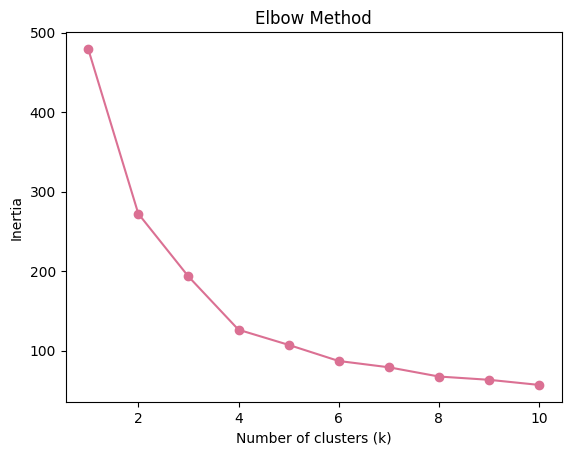

In [19]:
#Task 2: K-Means Clustering
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o', linestyle='-', color='palevioletred')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

<h1>Elbow Method</h1>
The Elbow Method was used to determine the optimal number of clusters by plotting inertia values for K ranging from 1 to 10. The graph showed a sharp decrease initially, followed by a gradual flattening. The elbow point was observed at K = 5, indicating the optimal number of clusters

In [33]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(pca_df)

pca_df['Cluster'] = clusters

K-Means clustering was performed using K = 5. Each data point was assigned a cluster label, which was added to the PCA-transformed dataset.

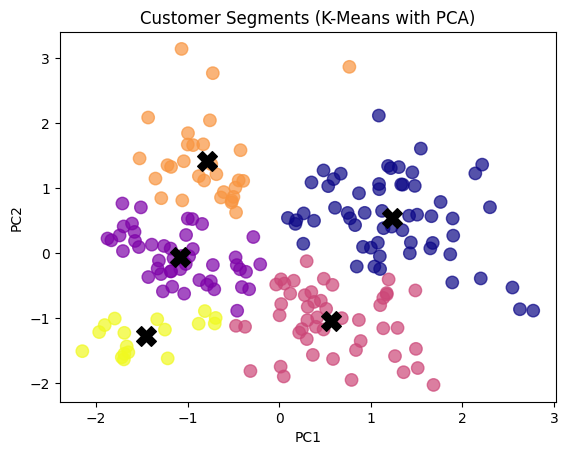

In [34]:
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='plasma', alpha=0.7, s= 80)
plt.scatter(kmeans.cluster_centers_[:,0], 
            kmeans.cluster_centers_[:,1],
            c='black', alpha=1, 
            s=200, marker='X')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (K-Means with PCA)')
plt.show()

<h1>Visualization</h1>
A scatter plot of PC1 vs PC2 was created, with points colored based on their cluster labels. The centroids were plotted on the same graph, clearly showing distinct customer segments.

<b><h4>Task 3: Lab Report Discussion Questions</h4></b>

<b>1. Feature Contribution: Look at the PCA components. Which original features 
(e.g., Income or Spending Score) seem to influence PC1 the most? </b>

In [35]:
print(pca.components_)

[[ 0.23430156  0.68790025 -0.00608217 -0.68691996]
 [ 0.62688553 -0.10368955  0.7652519   0.10321115]]


The first principal component (PC1) is mainly influenced by Age and Spending Score, showing a strong inverse relationship between them. This suggests that younger customers tend to spend more, while older customers spend less. The second principal component (PC2) is primarily influenced by Annual Income, along with Gender, indicating that income plays a major role in customer segmentation.

<b>2. The Centroid Profile: Look at the average values of the original features for one 
specific cluster. If you were the Mall Manager, what would you name this group? 
(e.g., "The Frugal Seniors" or "The Young Spenders").</b>

In [36]:
df['Cluster'] = clusters

df.groupby('Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,123.189655,0.775862,49.068966,70.344828,28.568966
1,102.085106,0.297872,27.127660,59.446809,66.404255
2,64.479167,0.062500,47.291667,45.104167,37.895833
3,152.066667,0.866667,31.066667,85.700000,72.766667
4,29.411765,0.000000,26.294118,29.529412,74.117647


Cluster analysis reveals distinct customer groups. For example, Cluster 3 represents ‘Premium Customers’ with high income and high spending, making them the most valuable segment. Cluster 2 consists of ‘Young Spenders’ who have low income but high spending behavior. Cluster 0 includes ‘Conservative Wealthy’ customers who have high income but low spending. These insights help the mall management design targeted marketing strategies for each group.

<b>3. The PCA Advantage: Why is it easier to perform K-Means on PCA components 
rather than the original 4-dimensional data? Discuss the "Curse of 
Dimensionality."</b>

Applying K-Means on PCA components improves clustering because it reduces dimensionality and removes redundant information. In high-dimensional space, due to the Curse of Dimensionality, distance-based algorithms like K-Means become less effective. PCA transforms the data into a lower-dimensional space where clusters are more separable and meaningful.”